# What is UMAP?

UMAP (Uniform Manifold Approximation and Projection) is a nonlinear dimensionality reduction technique used to visualize high-dimensional datasets.

Like PCA and t-SNE, UMAP reduces thousands of molecular features into two or three dimensions.

However, UMAP is designed to preserve both local neighborhood relationships and the overall global structure of the data.

As a result, UMAP often produces meaningful chemical space visualizations while being significantly faster than t-SNE on large molecular datasets.

## Why Do We Need UMAP?

PCA is fast but may fail to capture nonlinear relationships.

t-SNE produces excellent local clusters but often distorts the global arrangement of the data.

UMAP attempts to preserve both local and global relationships while remaining computationally efficient.

For this reason, UMAP has become one of the most popular dimensionality reduction techniques in cheminformatics and machine learning.

In [1]:
# Import Libraries

import pandas as pd
import numpy as np

from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator

import umap

import matplotlib.pyplot as plt

C:\Users\kiran\anaconda3\envs\chemtox_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load ESOL Dataset

df = pd.read_csv("esol_raw.csv")

df = df[["smiles", "measured log solubility in mols per litre"]]

df["Mol"] = df["smiles"].apply(Chem.MolFromSmiles)

df = df[df["Mol"].notnull()]

In [3]:
df

,smiles,measured log solubility in mols per litre,Mol
0,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,-0.770,<rdkit.Chem.rdchem.Mol object at 0x00000267780...
1,Cc1occc1C(=O)Nc2ccccc2,-3.300,<rdkit.Chem.rdchem.Mol object at 0x00000267780...
2,CC(C)=CCCC(C)=CC(=O),-2.060,<rdkit.Chem.rdchem.Mol object at 0x00000267780...
3,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,-7.870,<rdkit.Chem.rdchem.Mol object at 0x00000267780...
4,c1ccsc1,-1.330,<rdkit.Chem.rdchem.Mol object at 0x00000267780...
...,...,...,...
1123,FC(F)(F)C(Cl)Br,-1.710,<rdkit.Chem.rdchem.Mol object at 0x00000267781...
1124,CNC(=O)ON=C(SC)C(=O)N(C)C,0.106,<rdkit.Chem.rdchem.Mol object at 0x00000267781...
1125,CCSCCSP(=S)(OC)OC,-3.091,<rdkit.Chem.rdchem.Mol object at 0x00000267781...
1126,CCC(C)C,-3.180,<rdkit.Chem.rdchem.Mol object at 0x00000267781...


In [5]:
# Generate Morgan Fingerprints

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(
    radius=2,
    fpSize=2048
)

fingerprints = []

for mol in df["Mol"]:
    fp = morgan_gen.GetFingerprintAsNumPy(mol)
    fingerprints.append(fp)

X = np.array(fingerprints)
print("Fingerprint Matrix Shape:", X.shape)

Fingerprint Matrix Shape: (1128, 2048)


In [6]:
# Apply UMAP

reducer = umap.UMAP(
    n_components=2,
    random_state=42
)

X_umap = reducer.fit_transform(X)

print(X_umap.shape)

C:\Users\kiran\anaconda3\envs\chemtox_env\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\kiran\anaconda3\envs\chemtox_env\lib\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


(1128, 2)


In [8]:
# Add Coordinates

df["UMAP1"] = X_umap[:, 0]
df["UMAP2"] = X_umap[:, 1]

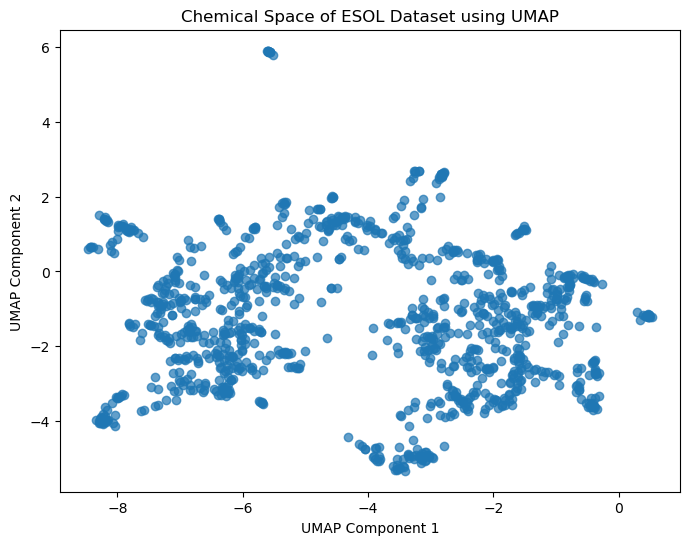

In [9]:
# Plot Chemical Space

plt.figure(figsize=(8,6))

plt.scatter(
    df["UMAP1"],
    df["UMAP2"],
    alpha=0.7
)

plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")
plt.title("Chemical Space of ESOL Dataset using UMAP")

plt.show()

## Interpretation

The UMAP plot represents the chemical space of the ESOL dataset using Morgan fingerprints.

Each point corresponds to one molecule.

UMAP groups structurally similar molecules into compact clusters while preserving meaningful relationships between different molecular families.

Compared with PCA, UMAP provides much better separation of molecular clusters.

Compared with t-SNE, UMAP preserves both local neighborhoods and the broader organization of the dataset, making it easier to interpret the overall chemical space.

Several well-defined clusters and a few isolated outliers are visible, indicating the presence of different scaffold families and structurally unique molecules within the ESOL dataset.

Because of its speed and ability to preserve both local and global relationships, UMAP has become one of the most widely used dimensionality reduction techniques for chemical space visualization in modern cheminformatics.